In [6]:
import numpy as np
import random
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification

# ----------------------------
# PLA in Python (book-style)
# ----------------------------

N = 100  # number of samples to generate
np.random.seed(7)  # for reproducibility (Python's random)

# Generate a 2D, linearly separable dataset
X, y = make_classification(
    n_samples=N,
    n_features=2,
    n_classes=2,
    n_informative=2,
    n_redundant=0,
    n_repeated=0,
    n_clusters_per_class=1,
    class_sep=1.1,
    random_state=5
)

# Convert labels {0,1} -> {-1,+1}
y[y == 0] = -1

# Add a column of ones (bias trick)
X_train = np.append(np.ones((N, 1)), X, axis=1)



In [7]:
# ----------------------------
# Helper: classification_error
# ----------------------------
# How many points are currently misclassified?
def classification_error(w, X, y):
    s = np.sign(X.dot(w))
    return np.sum(s != y)

# ----------------------------
# Helper: choose_miscl_point
# ----------------------------
# Give me ONE point that is currently classified wrong.
def choose_miscl_point(w, X, y):
    mispts = []
    for n in range(len(X)):
        if np.sign(w.T.dot(X[n])) != y[n]:
            mispts.append((X[n], y[n]))
    # pick one misclassified point at random
    return mispts[random.randrange(0, len(mispts))]


# Optimized version shown in the book (returns first found in random order)
def choose_miscl_point_fast(w, X, y):
    for idx in np.random.permutation(len(X)):
        if np.sign(w.T.dot(X[idx])) != y[idx]:
            return X[idx], y[idx]



In [8]:
# ----------------------------
# Train PLA
# ----------------------------
w = np.zeros(X_train.shape[1])   # initialize weights to zeros
w

array([0., 0., 0.])

Total iterations: 30
Final w: [-2.          8.24796045 -1.75962039]


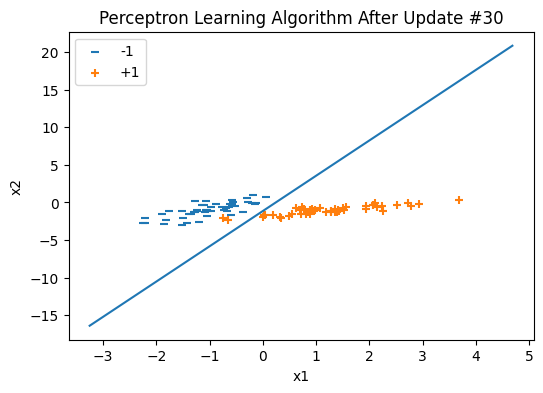

In [9]:
it = 0
max_updates = 30  # safety cap
# Iterate until all points are correctly classified
while classification_error(w, X_train, y) != 0 and it < max_updates:
    it += 1
    x_i, s = choose_miscl_point(w, X_train, y)   # or choose_miscl_point_fast(...)
    w = w + s * x_i

print("Total iterations:", it)
print("Final w:", w)

# ----------------------------
# Plot data + decision boundary (like the book figure)
# ----------------------------
plt.figure(figsize=(6, 4))
plt.scatter(X[y == -1, 0], X[y == -1, 1], marker='_', label='-1')
plt.scatter(X[y == +1, 0], X[y == +1, 1], marker='+', label='+1')

# Decision boundary: w0 + w1*x1 + w2*x2 = 0  ->  x2 = -(w0 + w1*x1)/w2
x1_vals = np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 200)
x2_vals = -(w[0] + w[1] * x1_vals) / w[2]
plt.plot(x1_vals, x2_vals)

plt.xlabel("x1")
plt.ylabel("x2")
plt.title(f"Perceptron Learning Algorithm After Update #{it}")
plt.legend()
plt.show()

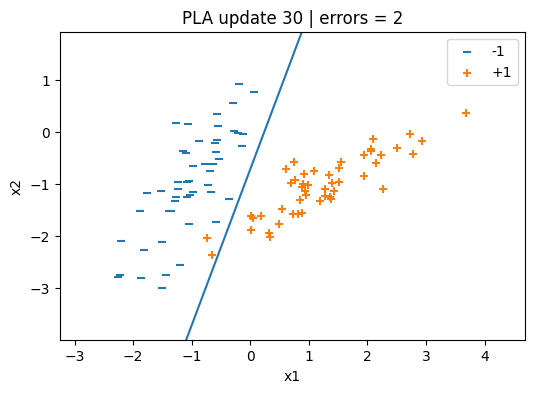

Final w: [-2.          8.40253581 -2.80203733]
Iteration: 30


In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from IPython.display import clear_output
import time

# --- data ---
X2, y01 = make_classification(
    n_samples=100, n_features=2, n_classes=2,
    n_informative=2, n_redundant=0,
    n_clusters_per_class=1, class_sep=1.1,
    random_state=5
)
y = np.where(y01 == 0, -1, +1)

# bias trick
X = np.c_[np.ones(len(X2)), X2]

def predict_sign(X, w):
    return np.sign(X @ w)

def choose_miscl_point(w, X, y):
    idx = np.where(predict_sign(X, w) != y)[0]
    j = np.random.choice(idx)
    return X[j], y[j]

def plot_boundary(ax, w, xlim):
    xs = np.linspace(xlim[0], xlim[1], 200)
    # handle vertical / degenerate cases
    if abs(w[2]) < 1e-12:
        if abs(w[1]) < 1e-12:
            return
        ax.axvline(-w[0] / w[1])
    else:
        ys = -(w[0] + w[1] * xs) / w[2]
        ax.plot(xs, ys)

# --- training + step-by-step display ---
w = np.zeros(X.shape[1])
max_updates = 30

xlim = (X2[:, 0].min() - 1, X2[:, 0].max() + 1)
ylim = (X2[:, 1].min() - 1, X2[:, 1].max() + 1)

for it in range(1, max_updates + 1):
    # compute errors BEFORE update (so title matches book style)
    errors = np.sum(predict_sign(X, w) != y)
    if errors == 0:
        # clear_output(wait=True)
        print("Converged!")
        break

    # update FIRST so we see a line immediately
    x_i, s = choose_miscl_point(w, X, y)
    w = w + s * x_i

    clear_output(wait=True)

    fig, ax = plt.subplots(figsize=(6,4))
    ax.scatter(X2[y == -1, 0], X2[y == -1, 1], marker='_', label="-1")
    ax.scatter(X2[y == +1, 0], X2[y == +1, 1], marker='+', label="+1")
    plot_boundary(ax, w, xlim=xlim)

    ax.set_xlim(*xlim); ax.set_ylim(*ylim)
    ax.set_xlabel("x1"); ax.set_ylabel("x2")
    ax.set_title(f"PLA update {it} | errors = {errors}")
    ax.legend(loc="best")
    plt.show()

    time.sleep(0.6)

print("Final w:", w)
print("Iteration:", it)